# 02 — DMD Tracking & Mode Structure

This notebook executes the sliding-window BOP-DMD fit across the discharge and extracts the physical properties of the coherent oscillation. We first establish that the mode exists and tracks the STFT ridge, then we prove that it takes the form of a physical standing wave (a real mode with distinct nodes) across the plasma, and finally, we verify that this spatial structure persists continuously throughout the discharge.

In [1]:
# Imports

import sys, os
sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import median_filter

from src import config as cfg
from src.math_helpers import load_data, get_reference_spectrogram, energy_fraction
from src.dmd_tracking import run_sliding_optdmd, track_mode, fit_one_window
from src.spatial_math import spatial_mode_analysis, spatial_mode_evolution

In [2]:
# Load base data and STFT ridge reference

ctx = load_data()
ref = get_reference_spectrogram(ctx)

## 1. Candidate Selection Walkthrough

Below is an example of the candidate selection process for a single window (at $t=4.0$ s, inside the frequency plateau).

The most energetic pole overall is actually low-frequency broadband turbulence. By bounding our selection to an eligible region around the STFT reference ridge (shaded blue), we cleanly isolate the coherent high-frequency mode.

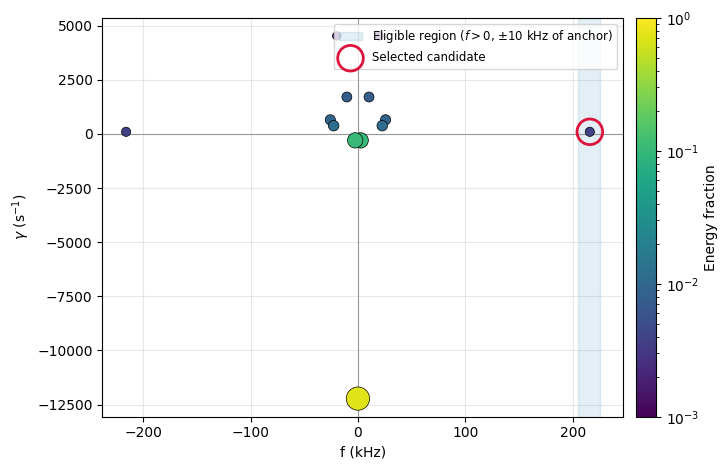

In [3]:
# Fit a single representative window
example = fit_one_window(ctx, ref, tc=4.0)

f, g = example['f'], example['gamma']
efrac = energy_fraction(example['amplitudes'])
seed_stft = float(np.interp(example['t'], ref['ridge_t_valid'], ref['ridge_f_valid']))

fig, ax = plt.subplots(figsize=(7.5, 4.8))

# Highlight the eligible search band
ax.axvspan((seed_stft - cfg.MODE_BAND_MARGIN) / 1e3, (seed_stft + cfg.MODE_BAND_MARGIN) / 1e3,
           color='tab:blue', alpha=0.12, label=r'Eligible region ($f>0$, $\pm$10 kHz of anchor)')
ax.axhline(0, color='0.6', lw=0.8)
ax.axvline(0, color='0.6', lw=0.8)

# Scatter all poles, sized and coloured by energy fraction
sizes = 25 + 300 * np.sqrt(efrac)
sc = ax.scatter(f / 1e3, g, s=sizes, c=efrac, cmap='viridis',
                norm=mcolors.LogNorm(vmin=1e-3, vmax=1), edgecolor='k', linewidth=0.5, zorder=3)

# Ring the selected candidate
sel = example['sel_idx']
ax.scatter([f[sel] / 1e3], [g[sel]], s=340, facecolors='none', edgecolors='crimson',
           linewidths=2, zorder=4, label='Selected candidate')

ax.set_xlabel('f (kHz)')
ax.set_ylabel(r'$\gamma$ (s$^{-1}$)')
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(alpha=0.3)
fig.colorbar(sc, ax=ax, label='Energy fraction', pad=0.02)
fig.tight_layout()
plt.show()

## 2. Sliding Window Tracking
We apply BOP-DMD at `WIN_PRIMARY` (0.5 ms) across the discharge. The target frequency for candidate selection is adaptively anchored to the STFT ridge to prevent the algorithm from hopping to high-variance background turbulence.

(Note: The fit takes ~40 minutes fresh. It is cached to `out/` so subsequent runs load instantly.)

In [4]:
checkpoint_file = os.path.join(cfg.OUT, 'discharge1_dmd_traces.pkl')

# Run sliding fit (or load from cache)
rows = run_sliding_optdmd(ctx, ref, checkpoint_path=checkpoint_file)

# Extract f(t), gamma(t), and eigenvectors phi(t)
track = track_mode(rows)

print(f"Tracked {len(track['t'])} windows.")
print(f"Mean Gamma: {track['gamma'].mean():+.0f} /s")

Tracked 166 windows.
Mean Gamma: -226 /s


### Tracking Diagnostics
We verify the tracking by overlaying $f(t)$ on the STFT spectrogram. Below that, we check $\gamma(t)$ and the candidate energy fraction.

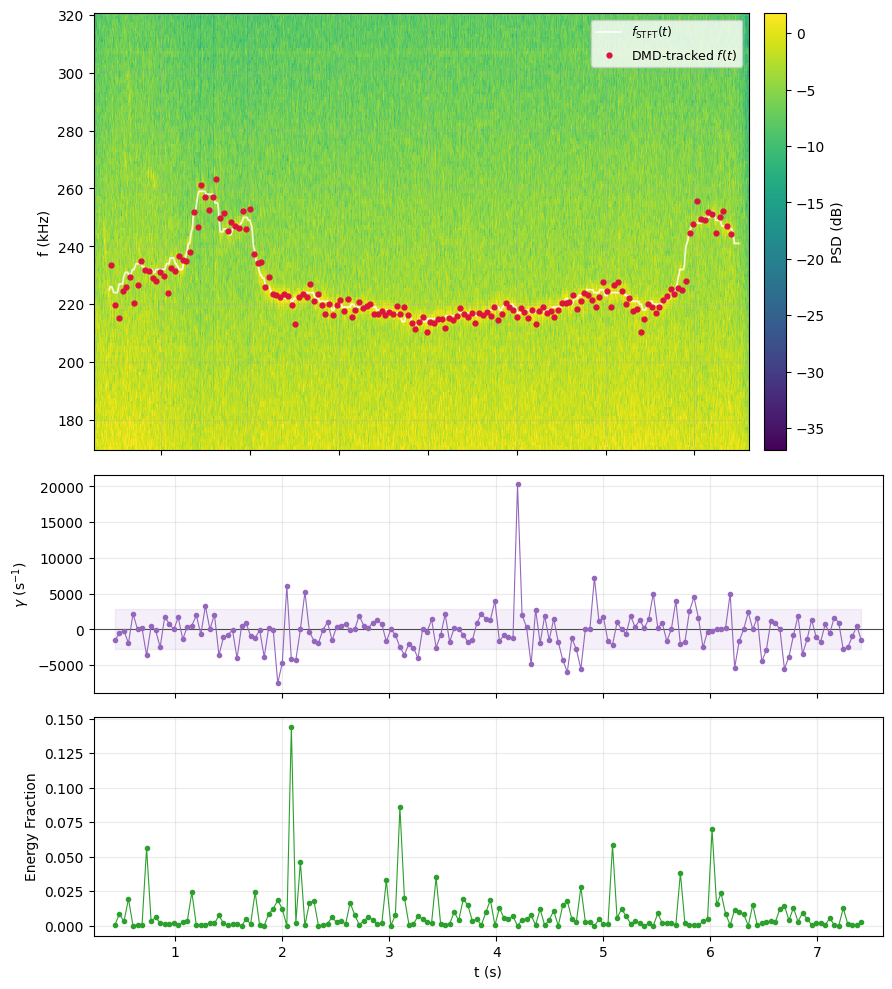

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(9, 10), gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=True)

# Spectrogram Overlay
disp = (ref['f'] >= cfg.SEARCH_BAND[0] - 20e3) & (ref['f'] <= cfg.SEARCH_BAND[1] + 20e3)
im = ax[0].pcolormesh(ref['t'], ref['f'][disp] / 1e3, ref['Sxx_db'][disp], 
                      shading='auto', cmap='viridis', 
                      vmin=np.percentile(ref['Sxx_db'][disp], 10), 
                      vmax=np.percentile(ref['Sxx_db'][disp], 99.9))
ax[0].plot(ref['ridge_t_valid'], ref['ridge_f_valid'] / 1e3, color='w', lw=1.2, alpha=0.85, label=r'$f_{\mathrm{STFT}}(t)$')
ax[0].plot(track['t'], track['f'] / 1e3, 'o', color='crimson', ms=3.5, label='DMD-tracked $f(t)$')
ax[0].set_ylabel('f (kHz)')
ax[0].legend(loc='upper right', fontsize=9)
fig.colorbar(im, ax=ax[0], pad=0.02, label='PSD (dB)')

# Gamma
std_g = track['gamma'].std()
ax[1].axhline(0, color='0.3', lw=0.8)
ax[1].fill_between(track['t'], -std_g, std_g, color='tab:purple', alpha=0.10)
ax[1].plot(track['t'], track['gamma'], 'o-', ms=3, lw=0.8, color='tab:purple')
ax[1].set_ylabel(r'$\gamma$ (s$^{-1}$)')

# Energy Fraction
ax[2].plot(track['t'], track['energy_frac'], 'o-', ms=3, lw=0.8, color='tab:green')
ax[2].set_ylabel('Energy Fraction')
ax[2].set_xlabel('t (s)')

for a in ax:
    a.grid(alpha=0.25)
    a.set_xlim(track['t'].min() - 0.2, track['t'].max() + 0.2)

fig.tight_layout()
plt.show()

## 3. Averaged Spatial Structure

To reveal the spatial structure, we average the complex mode vector $\phi$ over the most stable/"flat" stretch of the discharge. We fit a real mode shape (a standing wave) using Principal Component Analysis on the (Re, Im) point cloud. 

If this is a physical standing wave, we expect a high $R^2$ variance captured by a single global phase, and we expect the physical phase to flip exactly where the amplitude dips (the nodes).

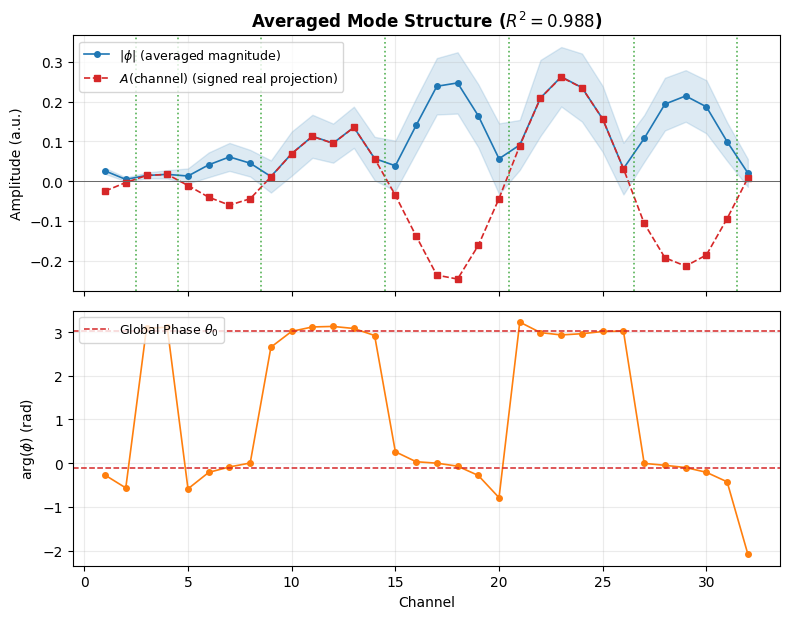

In [6]:
spatial = spatial_mode_analysis(ctx, track)

ch, A = spatial['ch'], spatial['A_avg']
mag, std = np.abs(spatial['phi_mean']), spatial['phi_std']
theta0 = spatial['theta0_avg']

fig, ax = plt.subplots(2, 1, figsize=(8, 6.3), sharex=True)

# Amplitude Panel
ax[0].fill_between(ch, mag - std, mag + std, color='tab:blue', alpha=0.15)
ax[0].plot(ch, mag, 'o-', ms=4, color='tab:blue', lw=1.2, label=r'$|\phi|$ (averaged magnitude)')
ax[0].plot(ch, A, 's--', ms=4, color='tab:red', lw=1.2, label=r'$A(\mathrm{channel})$ (signed real projection)')
ax[0].axhline(0, color='0.4', lw=0.7)

for sc in spatial['sign_changes']:
    ax[0].axvline(ch[sc] + 0.5, color='tab:green', lw=1.2, ls=':', alpha=0.8)
ax[0].set_ylabel('Amplitude (a.u.)')
ax[0].set_title(f"Averaged Mode Structure ($R^2 = {spatial['r2_real_avg']:.3f}$)", fontweight='bold')
ax[0].legend(loc='upper left', fontsize=9)

# Phase Panel
theta_lo = theta0 + np.pi if theta0 < 0 else theta0 - np.pi
ax[1].plot(ch, spatial['phase_display'], 'o-', ms=4, color='tab:orange', lw=1.2)
ax[1].axhline(theta0, color='tab:red', ls='--', lw=1.1, label=r'Global Phase $\theta_0$')
ax[1].axhline(theta_lo, color='tab:red', ls='--', lw=1.1)

ax[1].set_ylabel(r'$\arg(\phi)$ (rad)')
ax[1].set_xlabel('Channel')
ax[1].legend(loc='upper left', fontsize=9)

for a in ax: a.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 4. Spatial Continuity vs. Time
Finally, does this shape persist? We plot kymographs of the mode amplitude and phase to see the nodes holding steady across seconds. 

We also compute the vector overlap ($|\langle \phi_i, \phi_{\mathrm{ref}} \rangle|$) against our averaged reference. High overlap confirms the algorithm is tracking a single, continuously-evolving physical eigenmode, rather than jumping between disconnected transient artifacts. Note that the overlap is not plotted per window, but as the median of the current window and the three before + three after it (to make trends clearer).

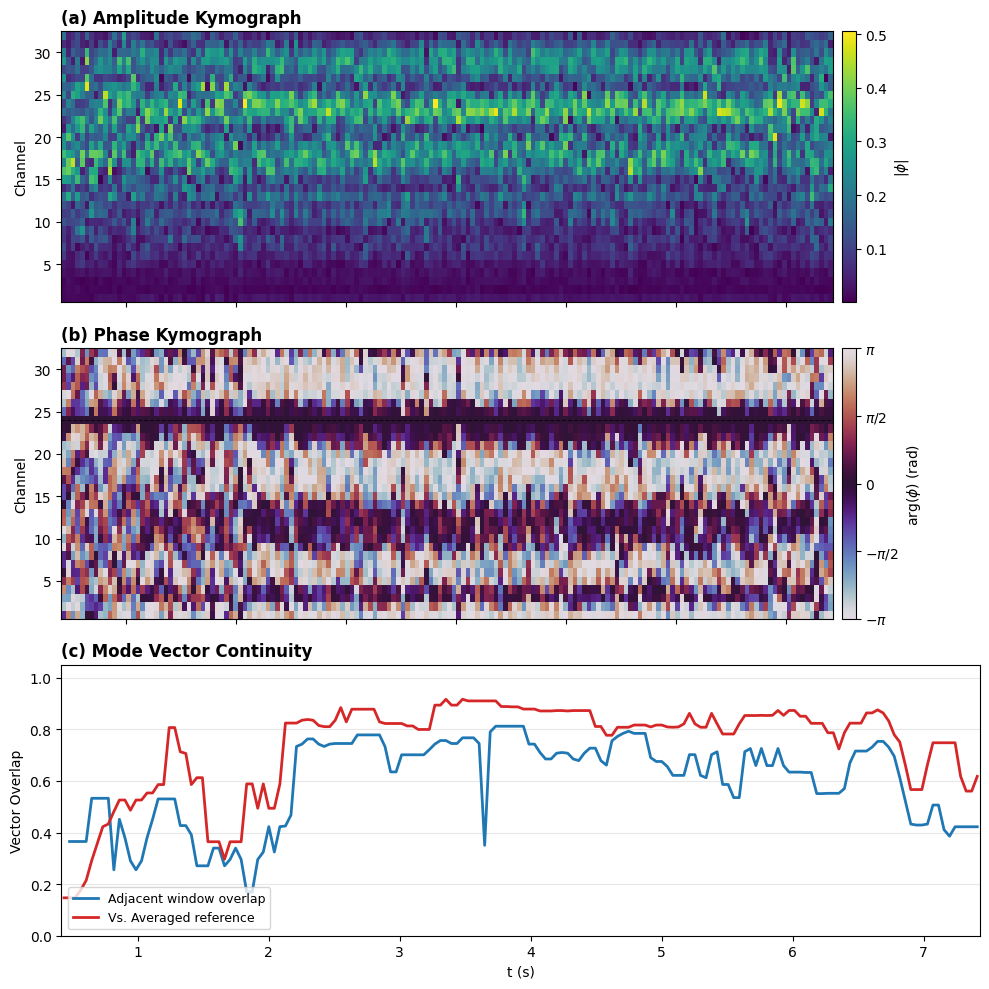

In [7]:
evol = spatial_mode_evolution(ctx, track, spatial)

fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Amplitude Kymograph
mag_im = ax[0].pcolormesh(evol['t'], evol['ch'], np.abs(evol['phi_n']).T, shading='nearest', cmap='viridis')
ax[0].set_ylabel('Channel')
ax[0].set_title('(a) Amplitude Kymograph', loc='left', fontweight='bold')
fig.colorbar(mag_im, ax=ax[0], pad=0.01, label=r'$|\phi|$')

# Phase Kymograph
ph_im = ax[1].pcolormesh(evol['t'], evol['ch'], np.angle(evol['phi_aligned']).T, 
                         shading='nearest', cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax[1].axhline(evol['ref_idx'] + 1, color='k', lw=0.8, ls='--', alpha=0.7)
ax[1].set_ylabel('Channel')
ax[1].set_title('(b) Phase Kymograph', loc='left', fontweight='bold')
cb1 = fig.colorbar(ph_im, ax=ax[1], pad=0.01, label=r'$\arg(\phi)$ (rad)')
cb1.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cb1.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

# Continuity Overlap
t_adj = evol['t'][1:]
smooth_window = 7
adj_smooth = median_filter(evol['overlap_adj'], size=min(smooth_window, len(evol['overlap_adj'])))
ref_smooth = median_filter(evol['overlap_ref'], size=min(smooth_window, len(evol['overlap_ref'])))

ax[2].plot(t_adj, adj_smooth, '-', lw=2, color='tab:blue', label=r'Adjacent window overlap')
ax[2].plot(evol['t'], ref_smooth, '-', lw=2, color='tab:red', label=r'Vs. Averaged reference')
ax[2].set_ylim(0, 1.05)
ax[2].set_ylabel('Vector Overlap')
ax[2].set_xlabel('t (s)')
ax[2].set_title('(c) Mode Vector Continuity', loc='left', fontweight='bold')
ax[2].legend(loc='lower left', fontsize=9)
ax[2].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()